# ACT Demo: Verification with VNNLib

Complete verification workflow using ACT framework with VNNLib benchmarks:
1. **Model Loading**: Load VNNLib benchmark and synthesize models
2. **Verification**: IntervalTF (forward bounds) + DualTF (certified bounds)
3. **Analysis**: Spurious counterexample inference

In [1]:
# Setup and imports
import sys, os 
import io
from contextlib import redirect_stdout

f = io.StringIO()
# with redirect_stdout(f):
#     from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
#     from act.front_end.model_synthesis import synthesize_models_from_specs
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import logging
# Configure logging: suppress verbose INFO logs from vnnlib_loader
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)
import torch
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
from collections import Counter

# Force reload modules
import importlib
modules_to_reload = [
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.dual_tf import DualTF, compute_forward_bounds
from act.back_end.solver import DualSolver
from act.back_end.analyze import analyze, initialize_tf_mode
from act.back_end.core import Bounds, Fact, ConSet
from act.util.device_manager import initialize_device

# Use CUDA + float64 (user requirement: GPU execution)
initialize_device('cuda', 'float64')

# CIFAR-100 class names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("Setup complete")

[ACT] Auto-detecting project root: ..
[WARN] Gurobi license not found: ../modules/gurobi/gurobi.lic
[INFO] Please place gurobi.lic in: ../modules/gurobi


✅ Device Manager Initialized: device=cuda:0, dtype=torch.float64
Setup complete


## Step 1: Load VNNLib Benchmark and Synthesize Models

In [2]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

# Load VNNLib instances
creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=3,
    validate_shapes=True
)
print(f"Loaded {len(spec_results)} instances\n")

# Synthesize wrapped models
print("Synthesizing wrapped models...")
wrapped_models = synthesize_models_from_specs(spec_results)
print(f"Synthesized {len(wrapped_models)} wrapped models\n")

# Extract instance info for all models
instance_info = []
wrapped_models_list = list(wrapped_models.values())
combo_ids = list(wrapped_models.keys())

for idx, (combo_id, wrapped_model) in enumerate(wrapped_models.items()):
    input_layer = wrapped_model.input_layer
    labeled_input = input_layer.labeled_input
    input_spec_layer = wrapped_model.input_spec
    input_spec = input_spec_layer.spec
    epsilon = float((input_spec.ub - input_spec.lb).max())
    
    # Batched API: labels is tensor [B]; for demo display, take first sample
    labels = labeled_input.label
    true_label = int(labels.flatten()[0].item()) if isinstance(labels, torch.Tensor) else int(labels)
    
    instance_info.append({
        'index': idx,
        'combo_id': combo_id,
        'input_tensor': labeled_input.tensor,
        'true_label': true_label,
        'epsilon': epsilon,
        'input_spec': input_spec,
        'labeled_input': labeled_input
    })
    print(f"Instance {idx+1}: {CIFAR100_CLASSES[true_label]} (label={true_label}), eps={epsilon:.6f}")

print(f"\nReady for fuzzing and verification")

LOADING CIFAR-100 VNNLIB BENCHMARK


Loaded 3 instances

Synthesizing wrapped models...

🧬 Synthesizing models from 3 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 3
   Wrapped models: 1
Synthesized 1 wrapped models

Instance 1: bridge (label=12), eps=0.030590

Ready for fuzzing and verification


## Step 2: Convert to ACT Net for Verification

In [3]:
print("="*80)
print("CONVERTING TO ACT NET")
print("="*80)

# Use first instance for verification demo
demo_idx = 0
wrapped_model = wrapped_models_list[demo_idx]
info = instance_info[demo_idx]
input_tensor = info['input_tensor']
true_label = info['true_label']
input_spec = info['input_spec']
epsilon = info['epsilon']

print(f"Demo instance: {CIFAR100_CLASSES[true_label]} (label={true_label})")

# Convert to ACT Net
converter = TorchToACT(wrapped_model)
act_net = converter.run()

print(f"ACT layers: {len(act_net.layers)}")
# Calculate total variables from the ACT net (var IDs are 0-indexed)
all_vars = [v for layer in act_net.layers for v in layer.out_vars]
total_vars = max(all_vars) + 1 if all_vars else 0
print(f"Variables: {total_vars}")

# Show network structure summary
print(f"\nNetwork structure (first 5 and last 3 layers):")
for i, layer in enumerate(act_net.layers[:5]):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")
print("  ...")
for i, layer in enumerate(act_net.layers[-3:], len(act_net.layers)-3):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")

CONVERTING TO ACT NET
Demo instance: bridge (label=12)
ACT layers: 43
Variables: 214444

Network structure (first 5 and last 3 layers):
   0. INPUT           | Out vars:   9216
   1. INPUT_SPEC      | Out vars:   9216
   2. CONV2D          | Out vars:  14400
   3. RELU            | Out vars:  14400
   4. CONV2D          | Out vars:   8192
  ...
  40. RELU            | Out vars:    100
  41. DENSE           | Out vars:    100
  42. ASSERT          | Out vars:    100


## Step 3: IntervalTF - Layer-by-Layer Bounds Propagation

INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)
Input bounds: lb=[-1.8362, 1.7121], ub=[-1.8057, 1.7427]

Running forward interval propagation using IntervalTF...


Computed bounds for 43 layers



Layer  Kind                Vars  Width(mean)   Width(max)
-------------------------------------------------------
0      INPUT               9216       0.0294       0.0306
1      INPUT_SPEC          9216       0.0294       0.0306
2      CONV2D             43200       0.0833       0.2984
3      RELU               43200       0.0180       0.2984
4      CONV2D             24576       0.1346       0.9311
5      RELU               24576       0.0152       0.5858
6      CONV2D             24576       0.3820       3.3333
7      CONV2D             24576       0.0422       0.6435
8      ADD                24576       0.4242       3.4060
9      CONV2D             24576          nan          nan
...
38     FLATTEN             6144          nan          nan
39     DENSE                300          nan          nan
40     RELU                 300          nan          nan
41     DENSE                300          nan          nan
42     ASSERT               300          nan          nan


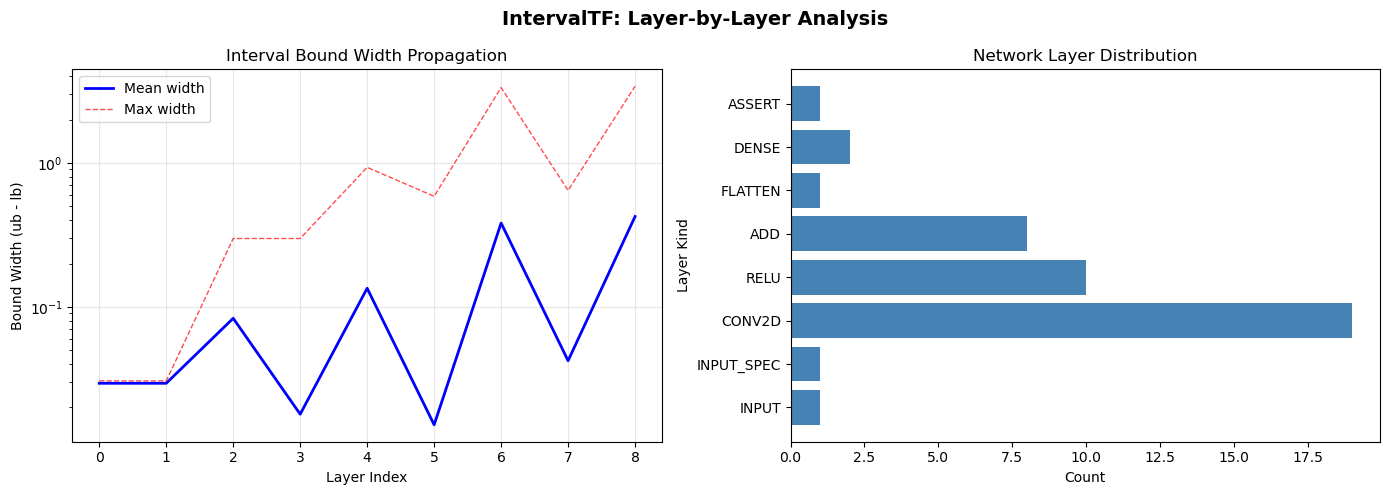


Key Observations:
  Input bound width (mean): 0.029446
  Output bound width (mean): nan
  Bound expansion ratio: nanx

Output layer bounds:
  Shape: torch.Size([3, 100])
  lb range: [nan, nan]
  ub range: [nan, nan]


In [4]:
print("="*80)
print("INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)")
print("="*80)

# Create input bounds from epsilon
if input_tensor.dim() == 4:
    input_flat = input_tensor.squeeze(0).flatten()
else:
    input_flat = input_tensor.flatten()

# Use bounds from input_spec (batch-native: keep [B, C, H, W] shape)
input_lb = input_spec.lb
input_ub = input_spec.ub

print(f"Input bounds: lb=[{input_lb.min():.4f}, {input_lb.max():.4f}], ub=[{input_ub.min():.4f}, {input_ub.max():.4f}]")

# Use IntervalTF via analyze() for proper bounds propagation
print("\nRunning forward interval propagation using IntervalTF...")
initialize_tf_mode("interval")  # Use IntervalTF

# Create entry fact with input bounds
entry_bounds = Bounds(lb=input_lb, ub=input_ub)
entry_fact = Fact(bounds=entry_bounds, cons=ConSet())

# Run analysis - returns (before, after, globalC)
entry_id = act_net.layers[0].id  # INPUT layer
before, after, globalC = analyze(act_net, entry_id, entry_fact)

# Convert after dict to bounds_dict format for compatibility with DualTF
bounds_dict = {lid: fact.bounds for lid, fact in after.items()}
print(f"Computed bounds for {len(bounds_dict)} layers")

# Collect layer statistics
layer_stats = []
for layer in act_net.layers:
    bounds = bounds_dict.get(layer.id)
    if bounds is not None:
        lb, ub = bounds.lb, bounds.ub
        width = (ub - lb)
        layer_stats.append({
            'id': layer.id,
            'kind': layer.kind,
            'num_vars': len(lb.flatten()),
            'width_mean': width.mean().item(),
            'width_max': width.max().item(),
            'lb_range': f"[{lb.min().item():.3f}, {lb.max().item():.3f}]",
            'ub_range': f"[{ub.min().item():.3f}, {ub.max().item():.3f}]",
        })

# Print table
print(f"\n{'Layer':<6} {'Kind':<15} {'Vars':>8} {'Width(mean)':>12} {'Width(max)':>12}")
print("-"*55)
for s in layer_stats[:10]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")
if len(layer_stats) > 15:
    print("...")
for s in layer_stats[-5:]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bound width evolution
layer_indices = range(len(layer_stats))
mean_widths = [s['width_mean'] for s in layer_stats]
max_widths = [s['width_max'] for s in layer_stats]

axes[0].plot(layer_indices, mean_widths, 'b-', label='Mean width', linewidth=2)
axes[0].plot(layer_indices, max_widths, 'r--', label='Max width', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Layer Index')
axes[0].set_ylabel('Bound Width (ub - lb)')
axes[0].set_title('Interval Bound Width Propagation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Layer kind distribution
kind_counts = Counter([s['kind'] for s in layer_stats])
kinds = list(kind_counts.keys())
counts = list(kind_counts.values())
axes[1].barh(kinds, counts, color='steelblue')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Layer Kind')
axes[1].set_title('Network Layer Distribution')

plt.suptitle('IntervalTF: Layer-by-Layer Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key observations
print(f"\nKey Observations:")
print(f"  Input bound width (mean): {layer_stats[0]['width_mean']:.6f}")
print(f"  Output bound width (mean): {layer_stats[-1]['width_mean']:.6f}")
expansion_ratio = layer_stats[-1]['width_mean'] / (layer_stats[0]['width_mean'] + 1e-10)
print(f"  Bound expansion ratio: {expansion_ratio:.2f}x")

# Store output bounds for DualTF
output_layer = act_net.layers[-2]  # Before ASSERT
output_bounds = bounds_dict.get(output_layer.id)
if output_bounds:
    print(f"\nOutput layer bounds:")
    print(f"  Shape: {output_bounds.lb.shape}")
    print(f"  lb range: [{output_bounds.lb.min():.4f}, {output_bounds.lb.max():.4f}]")
    print(f"  ub range: [{output_bounds.ub.min():.4f}, {output_bounds.ub.max():.4f}]")

## Step 4: DualTF - Robust Classification Bound

In [5]:
print("="*80)
print("DUAL TF VERIFICATION")
print("="*80)

# Step 1: Compute forward bounds (needed for dual backward pass)
print("\nComputing forward bounds...")
dual_bounds_dict = compute_forward_bounds(act_net, input_lb, input_ub)
print(f"Computed bounds for {len(dual_bounds_dict)} layers")

dual_tf = DualTF()
num_classes = 100
B_demo = dual_bounds_dict[act_net.layers[0].id].lb.shape[0]

# Step 2: Compute robust bound using DualSolver (replaces removed dual_tf.compute_robust_bound)
solver = DualSolver(dual_tf)
min_slack_batched, certified_batched = solver.compute_robust_bound(
    act_net, dual_bounds_dict, y_true=true_label, num_classes=num_classes,
)
min_margin = min_slack_batched[0]
is_certified = bool(certified_batched[0].item())

print(f"\nRobust verification result (batch sample 0):")
print(f"  True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Status: {'CERTIFIED' if is_certified else 'NOT CERTIFIED'}")

# Compute detailed margins for top adversarial classes
print(f"\nDetailed margins for top adversarial classes:")

# Get model prediction to find top classes
if input_tensor.dim() == 3:
    input_batch = input_tensor.unsqueeze(0)
else:
    input_batch = input_tensor

with torch.no_grad():
    orig_output = wrapped_model(input_batch)
    if isinstance(orig_output, dict):
        orig_output = orig_output['output']
    # Batched API: orig_output is [B, num_classes]; take first sample as demo
    orig_pred = int(orig_output.argmax(dim=1)[0].item())
    orig_conf = torch.softmax(orig_output[0], dim=0)[orig_pred].item()
    top10_classes = torch.topk(orig_output[0], k=10).indices.tolist()

print(f"\nOriginal prediction: {CIFAR100_CLASSES[orig_pred]} (conf: {orig_conf:.3f})")
print(f"Top 10 classes: {top10_classes}")

# Get output bounds from DualTF's bounds dict
dual_output_layer = act_net.layers[-2]  # Before ASSERT
dual_output_bounds = dual_bounds_dict.get(dual_output_layer.id)

# Compute margins
margins = []
for target_class in top10_classes:
    if target_class == true_label:
        continue
    
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[target_class] = -1.0
    
    # Replaces removed dual_tf.compute_bound; DualSolver expects c shaped [B, num_classes]
    c_batched = c.unsqueeze(0).expand(B_demo, -1).contiguous()
    margin_batched = solver.compute_bound(act_net, dual_bounds_dict, c_batched)
    margin = margin_batched[0]
    margins.append((target_class, margin.item()))
    
    status = "OK" if margin.item() > 0 else "VULNERABLE"
    print(f"  Class {target_class:3d} ({CIFAR100_CLASSES[target_class]:20s}): margin = {margin.item():8.4f} [{status}]")

# Find most vulnerable class
margins.sort(key=lambda x: x[1])
weakest_class, weakest_margin = margins[0]
print(f"\nMost vulnerable adversarial class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"Margin: {weakest_margin:.6f}")


DUAL TF VERIFICATION

Computing forward bounds...


Computed bounds for 43 layers



Robust verification result (batch sample 0):
  True label: 12 (bridge)
  Min margin: -1.914857
  Status: NOT CERTIFIED

Detailed margins for top adversarial classes:

Original prediction: bridge (conf: 0.583)
Top 10 classes: [12, 25, 5, 87, 17, 81, 37, 20, 39, 90]
  Class  25 (couch               ): margin =  -1.9149 [VULNERABLE]


  Class   5 (bed                 ): margin =  -0.6718 [VULNERABLE]
  Class  87 (television          ): margin =  -0.7866 [VULNERABLE]
  Class  17 (castle              ): margin =  -0.5034 [VULNERABLE]
  Class  81 (streetcar           ): margin =   0.6374 [OK]
  Class  37 (house               ): margin =   1.4068 [OK]


  Class  20 (chair               ): margin =   0.4852 [OK]
  Class  39 (keyboard            ): margin =   1.4394 [OK]
  Class  90 (train               ): margin =   1.3268 [OK]

Most vulnerable adversarial class: 25 (couch)
Margin: -1.914857


## Step4b: Forward bound  v.s. Backward bound Margin Comparison

In [6]:
# ============================================================================
# Compare Forward Bound vs Backward (Dual) Bound
# ============================================================================
print(f"\n" + "="*80)
print("FORWARD vs BACKWARD BOUND COMPARISON")
print("="*80)
print(f"  True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print()
print(f"  {'Class':<6} {'Name':<15} {'Forward':>12} {'Backward':>12} {'Improvement':>12} {'Status'}")
print(f"  {'-'*6} {'-'*15} {'-'*12} {'-'*12} {'-'*12} {'-'*8}")

for target_class in top10_classes:
    if target_class == true_label:
        continue
    
    # Forward bound (interval): lb[true] - ub[target] using compute_forward_bounds result
    forward_margin = (dual_output_bounds.lb.flatten()[true_label] - dual_output_bounds.ub.flatten()[target_class]).item()
    
    # Backward bound (dual): using DualTF backward pass
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[target_class] = -1.0
    c_batched = c.unsqueeze(0).expand(B_demo, -1).contiguous()
    backward_margin = solver.compute_bound(act_net, dual_bounds_dict, c_batched)[0].item()
    
    improvement = backward_margin - forward_margin
    status = 'TIGHTER' if improvement > 1e-6 else '-'
    print(f"  {target_class:<6} {CIFAR100_CLASSES[target_class]:<15} {forward_margin:>12.4f} {backward_margin:>12.4f} {improvement:>+12.4f} [{status}]")

print()
print("Note: Forward bound uses interval arithmetic (lb[true] - ub[target])")
print("      Backward bound uses dual/Lagrangian relaxation (tighter bounds)")


FORWARD vs BACKWARD BOUND COMPARISON
  True label: 12 (bridge)

  Class  Name                 Forward     Backward  Improvement Status
  ------ --------------- ------------ ------------ ------------ --------
  25     couch               -25.6234      -1.9149     +23.7085 [TIGHTER]
  5      bed                 -26.1905      -0.6718     +25.5187 [TIGHTER]


  87     television          -25.8743      -0.7866     +25.0878 [TIGHTER]
  17     castle              -26.4647      -0.5034     +25.9613 [TIGHTER]


  81     streetcar           -25.2472       0.6374     +25.8846 [TIGHTER]
  37     house               -24.1961       1.4068     +25.6030 [TIGHTER]
  20     chair               -26.0075       0.4852     +26.4928 [TIGHTER]
  39     keyboard            -22.6657       1.4394     +24.1051 [TIGHTER]
  90     train               -24.6848       1.3268     +26.0117 [TIGHTER]

Note: Forward bound uses interval arithmetic (lb[true] - ub[target])
      Backward bound uses dual/Lagrangian relaxation (tighter bounds)


## Step 5: Spurious Counterexample (false alarm) Analysis

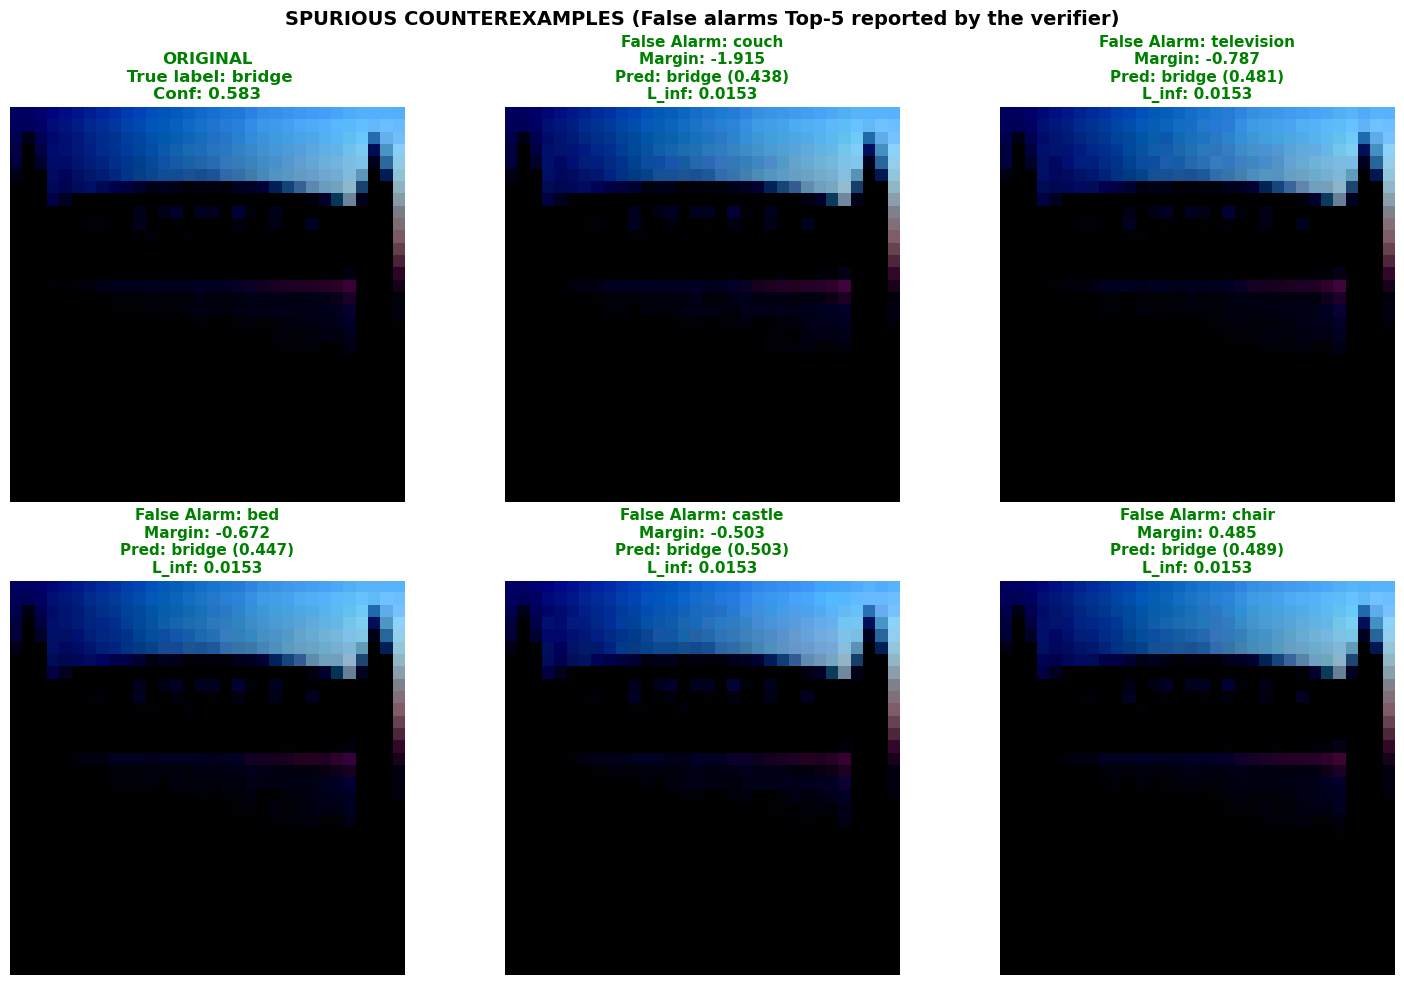


 AdvClass | ClassName            |     Margin | FA_pred | PredName             |     Conf |    L_inf |  Within_eps
-------------------------------------------------------------------------------------------------------------------
       25 | couch                |    -1.9149 |      12 | bridge               |   0.4381 |   0.0153 |        True
       87 | television           |    -0.7866 |      12 | bridge               |   0.4808 |   0.0153 |        True
        5 | bed                  |    -0.6718 |      12 | bridge               |   0.4473 |   0.0153 |        True
       17 | castle               |    -0.5034 |      12 | bridge               |   0.5030 |   0.0153 |        True
       20 | chair                |     0.4852 |      12 | bridge               |   0.4887 |   0.0153 |        True

Most vulnerable (min margin) in Top 5: 25 (couch)
Margin: -1.914857

RESULT: model maintains correct classification
  This is a false alarm (greedy boundary selection)
  Real adversarial may e

In [7]:


# Select the top 5 adversarial classes by margin (lowest 5 non-true_label in top10)
sce_infos = []
adv_class_candidates = []

# 1. Gather (adv_class, margin) for all top10 classes (excluding true_label)
# Use DualTF's bounds (dual_bounds_dict) for analysis
for adv_class in top10_classes:
    if adv_class == true_label:
        continue
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[adv_class] = -1.0
    c_batched = c.unsqueeze(0).expand(B_demo, -1).contiguous()
    margin = solver.compute_bound(act_net, dual_bounds_dict, c_batched)[0].item()
    adv_class_candidates.append((adv_class, margin))

# 2. Sort by margin, pick top 5 most vulnerable (lowest margins)
topk = 5
adv_class_sorted = sorted(adv_class_candidates, key=lambda x: x[1])[:topk]

# 3. For each of the top 5, generate input info
for adv_class, margin in adv_class_sorted:
    c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
    c[true_label] = 1.0
    c[adv_class] = -1.0
    c_batched = c.unsqueeze(0).expand(B_demo, -1).contiguous()
    margin_batched, sce_batched = solver.compute_bound(act_net, dual_bounds_dict, c_batched, return_sce=True)
    margin_val = margin_batched[0].item()
    sce_raw = sce_batched[0] if sce_batched is not None else torch.zeros(1)
    expected_size = 3 * 32 * 32  # image size for CIFAR

    # Recover image — take first batch sample if bounds are batched
    if sce_raw.numel() != expected_size:
        input_layer = act_net.layers[1]
        sce_input_bounds = dual_bounds_dict.get(input_layer.id)
        if sce_input_bounds is not None:
            sce_image = sce_input_bounds.lb[0:1].clone().reshape(1, 3, 32, 32) if sce_input_bounds.lb.dim() >= 4 else sce_input_bounds.lb.clone().reshape(1, 3, 32, 32)
        else:
            sce_image = input_tensor[0:1].clone() if input_tensor.dim() == 4 else input_tensor.clone()
    else:
        sce_image = sce_raw.reshape(1, 3, 32, 32)

    # Inference
    pytorch_model = wrapped_model.model
    pytorch_model.eval()
    with torch.no_grad():
        sce_output = pytorch_model(sce_image)
        sce_pred = sce_output.argmax(dim=1).item()
        sce_probs = torch.softmax(sce_output[0], dim=0)
        sce_conf = sce_probs[sce_pred].item()
        sce_target_conf = sce_probs[adv_class].item()

    # Perturbation w.r.t. original input — batched API: take first sample
    if input_tensor.dim() == 4:
        orig_tensor = input_tensor[0]
    else:
        orig_tensor = input_tensor
    diff = sce_image.squeeze() - orig_tensor.reshape(3, 32, 32).to(sce_image.device)
    l_inf = diff.abs().max().item()
    
    sce_infos.append({
        "adv_class": adv_class,
        "adv_class_name": CIFAR100_CLASSES[adv_class],
        "margin": margin_val,
        "sce_pred": sce_pred,
        "sce_pred_name": CIFAR100_CLASSES[sce_pred],
        "sce_conf": sce_conf,
        "sce_target_conf": sce_target_conf,
        "l_inf": l_inf,
        "sce_image": sce_image
    })

# 4. Visualization: 3x2 grid, first is ORIGINAL and five false alarms
import math
nrow, ncol = 2, 3
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*5, nrow*5))

# Plot original image in [0,0] — batched API: take first sample
if input_tensor.dim() == 4:
    orig_tensor = input_tensor[0]
else:
    orig_tensor = input_tensor
orig_img = orig_tensor.reshape(3, 32, 32).permute(1, 2, 0)
orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
axes[0,0].imshow(orig_img_np, interpolation='nearest')
axes[0,0].set_title(f'ORIGINAL\n True label: {CIFAR100_CLASSES[true_label]}\nConf: {orig_conf:.3f}', 
                    fontsize=12, color='green', fontweight='bold')
axes[0,0].axis('off')

for idx, info in enumerate(sce_infos):
    pos = idx + 1
    row = pos // ncol
    col = pos % ncol
    ax = axes[row, col]
    sce_img = info['sce_image'].squeeze().permute(1, 2, 0)
    sce_img_np = np.clip(sce_img.cpu().numpy(), 0, 1)
    ax.imshow(sce_img_np, interpolation='nearest')
    color = 'red' if info['sce_pred'] != true_label else 'green'
    ax.set_title(
        f"False Alarm: {info['adv_class_name']}\n"
        f"Margin: {info['margin']:.3f}\n"
        f"Pred: {info['sce_pred_name']} ({info['sce_conf']:.3f})\n"
        f"L_inf: {info['l_inf']:.4f}",
        fontsize=11, color=color, fontweight='bold'
    )
    ax.axis('off')

# Hide empty axes if any
for i in range(len(sce_infos) + 1, nrow*ncol):
    row = i // ncol
    col = i % ncol
    axes[row, col].axis('off')

plt.suptitle('SPURIOUS COUNTEREXAMPLES (False alarms Top-5 reported by the verifier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Table summary
header = (
    f"\n{'AdvClass':>9s} | {'ClassName':<20s} | {'Margin':>10s} | {'FA_pred':>7s} "
    f"| {'PredName':<20s} | {'Conf':>8s} | {'L_inf':>8s} | {'Within_eps':>11s}"
)
print(header)
print("-" * len(header))
for info in sce_infos:
    within_eps = info["l_inf"] <= epsilon
    print(
        f"{info['adv_class']:9d} | "
        f"{info['adv_class_name']:<20s} | "
        f"{info['margin']:10.4f} | "
        f"{info['sce_pred']:7d} | "
        f"{info['sce_pred_name']:<20s} | "
        f"{info['sce_conf']:8.4f} | "
        f"{info['l_inf']:8.4f} | "
        f"{str(within_eps):>11s}"
    )

# Also, summary for the one with lowest margin among the selected
min_info = min(sce_infos, key=lambda x: x["margin"])
print("\n" + "="*62)
print(f"Most vulnerable (min margin) in Top 5: {min_info['adv_class']} ({min_info['adv_class_name']})")
print(f"Margin: {min_info['margin']:.6f}")
print("="*62)

if min_info['sce_pred'] != true_label:
    if min_info['sce_pred'] == min_info['adv_class']:
        print(f"\nRESULT: True counterexample causes misclassification to TARGET class!")
    else:
        print(f"\nRESULT: True counterexample causes misclassification to different class: {min_info['sce_pred_name']}")
else:
    print("\nRESULT: model maintains correct classification")
    print("  This is a false alarm (greedy boundary selection)")
    print("  Real adversarial may exist but requires more sophisticated search")

## Step 6: Results Summary

In [8]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

print(f"\n[Model Information]")
print(f"  Benchmark: cifar100_2024")
print(f"  Instances tested: {len(instance_info)}")
print(f"  Demo instance: {CIFAR100_CLASSES[true_label]} (label={true_label})")
print(f"  Epsilon: {epsilon:.6f}")

print(f"\n[DualTF Verification]")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Certified: {is_certified}")
print(f"  Most vulnerable class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")


print(f"  false alarm prediction: {CIFAR100_CLASSES[sce_pred]}")
print(f"  Misclassification: {sce_pred != true_label}")
print(f"  Perturbation L_inf: {l_inf:.6f}")

print(f"\n[Conclusion]")
if is_certified:
    print(f"  Model is CERTIFIED ROBUST for this instance")
else:
    print(f"  Model is NOT CERTIFIED ROBUST")
    if sce_pred != true_label:
        print(f"  false alarm analysis suggests potential vulnerability to class {CIFAR100_CLASSES[sce_pred]}")
    else:
        print(f"  Further analysis recommended")

print("\n" + "="*80)
print("DEMO COMPLETE")
print("="*80)



COMPREHENSIVE RESULTS SUMMARY

[Model Information]
  Benchmark: cifar100_2024
  Instances tested: 1
  Demo instance: bridge (label=12)
  Epsilon: 0.030590

[DualTF Verification]
  Min margin: -1.914857
  Certified: False
  Most vulnerable class: 25 (couch)
  false alarm prediction: bridge
  Misclassification: False
  Perturbation L_inf: 0.015295

[Conclusion]
  Model is NOT CERTIFIED ROBUST
  Further analysis recommended

DEMO COMPLETE
